In [10]:
import h5py
import math
import numpy as np
import matplotlib.pyplot as plt

In [11]:
GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_relicd_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = 9

def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    file_path = f"../data/version-{version}/{file_name}"

    return h5py.File(file_path, "r")["MSSM"]

scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

In [12]:

mask = scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:] == 1
print(sum(mask))
lnL_oh2_gd = scan_gambit_diver["#lnL_oh2 @DarkBit::lnL_oh2_upperlimit"][mask]
oh2_gd = scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas"][mask]

mask = scan_gambit_random["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:] == 1
lnL_oh2_gr = scan_gambit_random["#lnL_oh2 @DarkBit::lnL_oh2_upperlimit"][mask]
oh2_gr = scan_gambit_random["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas"][mask]

mask = (scan_modelgen["MO_Omega"][:] != -1) & (scan_modelgen["MO_Omega"][:] < 1)
oh2_mg = scan_modelgen["MO_Omega"][mask]



17


## Likelihood Calculation

In [13]:
oh2_theory = np.linspace(0, 1, 1000)
oh2_theoryerr = 0.05
oh2_obs = 0.11933
oh2_obserr = 0.00091

In [14]:
def gaussian_upper_limit_loglike(theory, obs, theoryerr, obserr, profile_systematics: bool = False) -> float:
    """Calculate the log-likelihood for a Gaussian upper limit."""
    theoryerr *= theory
    errsq = theoryerr**2 + obserr**2
    if profile_systematics:
        prefactor = -0.5 * np.log(2*np.pi*errsq)
        loglike = prefactor - 0.5*np.power((theory - obs), 2)/errsq if theory > obs else prefactor
        return loglike
    else:
        prefactor = -0.5 * np.log(8*np.pi)
        diff = obs - theory
        like = np.exp(-0.5*diff**2/errsq)/np.sqrt(errsq)
        like *= math.erfc(obserr * diff / (theoryerr * np.sqrt(2*errsq)))
        like += math.erfc(-diff / (np.sqrt(2)*theoryerr))/obserr
        loglike = prefactor + 1.17549e-38 if like==0 else prefactor + np.log(like)
        return loglike

lnL_oh2_theory = [gaussian_upper_limit_loglike(oh2_theory[i], oh2_obs, oh2_theoryerr, oh2_obserr, profile_systematics=False) for i in range(len(oh2_theory))]
lnL_oh2_mg = [gaussian_upper_limit_loglike(oh2_mg[i], oh2_obs, oh2_theoryerr, oh2_obserr) for i in range(len(oh2_mg))]

/var/folders/db/y5gkptmd6k35lffw7bh2y3xr0000gn/T/ipykernel_1519/1081192430.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  like *= math.erfc(obserr * diff / (theoryerr * np.sqrt(2*errsq)))
/var/folders/db/y5gkptmd6k35lffw7bh2y3xr0000gn/T/ipykernel_1519/1081192430.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  like += math.erfc(-diff / (np.sqrt(2)*theoryerr))/obserr


In [15]:
print("SCAN             | VALID/ATTEMPTED")
print("-----------------------------------")
print(f"GAMBIT random    | {len(oh2_gr)}/{len(scan_gambit_random["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:])}\t{(len(oh2_gr)/len(scan_gambit_random["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:]))*100:.2f}%")
print(f"GAMBIT diver     | {len(oh2_gd)}/{len(scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:])}\t{(len(oh2_gd)/len(scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:]))*100:.2f}%")
print(f"MODELGEN         | {len(oh2_mg)}/{len(scan_modelgen["MO_Omega"][:])}\t{(len(oh2_mg)/len(scan_modelgen["MO_Omega"][:]))*100:.2f}%")

SCAN             | VALID/ATTEMPTED
-----------------------------------
GAMBIT random    | 30000/30000	100.00%
GAMBIT diver     | 17/14000	0.12%
MODELGEN         | 300/30000	1.00%


In [16]:
sig1_points_gr = oh2_gr[lnL_oh2_gr[:] > np.max(lnL_oh2_gr)-0.5]
sig1_points_gd = oh2_gd[lnL_oh2_gd[:] > np.max(lnL_oh2_gd)-0.5]
sig1_points_mg = oh2_mg[lnL_oh2_mg[:] > np.max(lnL_oh2_mg)-0.5]

acceptance_range = [
    0,
    0.1099 + 0.0062
]

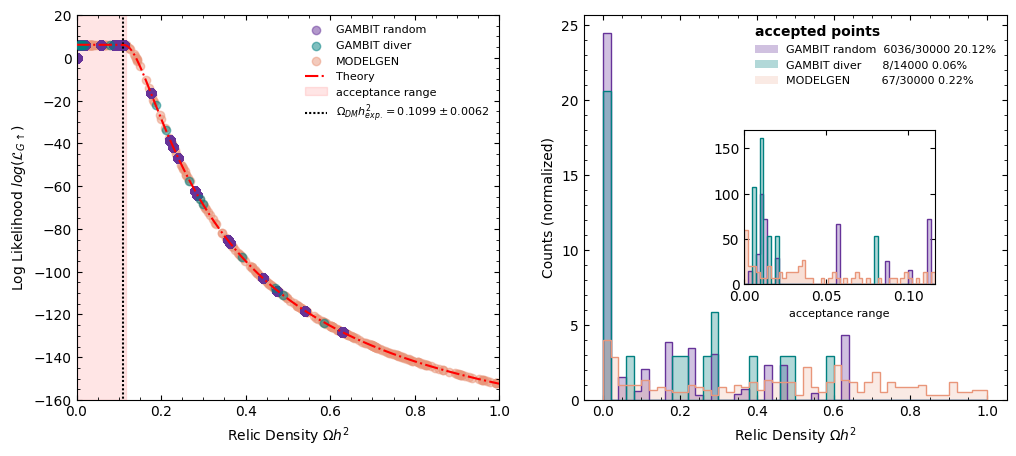

In [18]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.scatter(oh2_gr, lnL_oh2_gr, alpha=0.5, color='rebeccapurple', label="GAMBIT random", zorder=2)
ax1.scatter(oh2_gd, lnL_oh2_gd, alpha=0.5, color='teal', label="GAMBIT diver", zorder=3)
ax1.scatter(oh2_mg, lnL_oh2_mg, alpha=0.5, color='darksalmon', label="MODELGEN", zorder=1)
ax1.plot(oh2_theory, lnL_oh2_theory, color='red', linestyle='-.',zorder=5, label="Theory")
ax1.axvspan(acceptance_range[0], acceptance_range[1], color='red', alpha=0.1, zorder=0, label="acceptance range")
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax1.set_xlabel("Relic Density $\\Omega h^2$")
ax1.set_ylabel("Log Likelihood $log(\\mathcal{L}_{G \\uparrow})$")

# ax1.hlines(-140, xmin=0, xmax=np.max(sig1_points_mg), linestyles="--", colors='darksalmon',zorder=5)
# ax1.scatter(np.max(sig1_points_mg), -140, color="darksalmon", marker="|", s=100)
# ax1.errorbar(np.max(sig1_points_mg), -140, xerr=0.05*np.max(sig1_points_mg), fmt='none', color='grey', capsize=2, alpha=0.7)

# ax1.hlines(-120, xmin=0, xmax=np.max(sig1_points_gd), linestyles="--", colors='teal',zorder=5)
# ax1.scatter(np.max(sig1_points_gd), -120, color="teal", marker="|", s=100)
# ax1.errorbar(np.max(sig1_points_gd), -120, xerr=0.05*np.max(sig1_points_gd), fmt='none', color='grey', capsize=2, alpha=0.7)

# ax1.hlines(-100, xmin=0, xmax=np.max(sig1_points_gr), linestyles="--", colors='rebeccapurple',zorder=5)
# ax1.scatter(np.max(sig1_points_gr), -100, color="rebeccapurple", marker="|", s=100)
# ax1.errorbar(np.max(sig1_points_gr), -100, xerr=0.05*np.max(sig1_points_gr), fmt='none', color='grey', capsize=2, alpha=0.7)

ax1.vlines(0.1099, ymin=-200, ymax=20, linestyles=(0, (1, 1)), colors='black', label="$\\Omega_{DM}h_{exp.}^2 = 0.1099 \\pm 0.0062$")
ax1.set_ylim(-160,20)
ax1.set_xlim(0,1)

ax1.legend(frameon=False, fontsize=8)

ax2.hist(oh2_gr, bins=50, range=(0,1), density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label=f"GAMBIT random  {len(oh2_gr[lnL_oh2_gr[:] > np.max(lnL_oh2_gr)-0.5])}/{len(scan_gambit_random["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:])} {(len(oh2_gr[lnL_oh2_gr[:] > np.max(lnL_oh2_gr)-0.5])/len(scan_gambit_random["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:]))*100:.2f}%")
ax2.hist(oh2_gr, bins=50, range=(0,1), density=True, histtype='step', color='rebeccapurple')
ax2.hist(oh2_gd, bins=50, range=(0,1), density=True, alpha=0.3, histtype='stepfilled', color='teal', label=         f"GAMBIT diver      {len(oh2_gd[lnL_oh2_gd[:] > np.max(lnL_oh2_gd)-0.5])}/{len(scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:])} {(len(oh2_gd[lnL_oh2_gd[:] > np.max(lnL_oh2_gd)-0.5])/len(scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:]))*100:.2f}%")
ax2.hist(oh2_gd, bins=50, range=(0,1), density=True, histtype='step', color='teal')
ax2.hist(oh2_mg, bins=50, range=(0,1), density=True, alpha=0.2, histtype='stepfilled', color='darksalmon', label=   f"MODELGEN         {len(oh2_mg[lnL_oh2_mg[:] > np.max(lnL_oh2_mg)-0.5])}/{len(scan_modelgen["MO_Omega"][:])} {(len(oh2_mg[lnL_oh2_mg[:] > np.max(lnL_oh2_mg)-0.5])/len(scan_modelgen["MO_Omega"][:]))*100:.2f}%")
ax2.hist(oh2_mg, bins=50, range=(0,1), density=True, histtype='step', color='darksalmon')
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.set_xlabel("Relic Density $\\Omega h^2$")
ax2.set_ylabel("Counts (normalized)")
leg = ax2.legend(frameon=False, fontsize=8)
leg.set_title("accepted points", prop={'weight': 'bold'})
leg._legend_box.align = "left"

ax3 = ax2.inset_axes([0.38, 0.3, 0.45, 0.4], transform=ax2.transAxes)
ax3.hist(sig1_points_gr, bins=50, range=acceptance_range, density=True, histtype='stepfilled', alpha=0.3, facecolor='rebeccapurple')
ax3.hist(sig1_points_gd, bins=50, range=acceptance_range, density=True, histtype='stepfilled', alpha=0.3, facecolor='teal')
ax3.hist(sig1_points_mg, bins=50, range=acceptance_range, density=True, histtype='stepfilled', alpha=0.3, facecolor='darksalmon')
ax3.hist(sig1_points_gr, bins=50, range=acceptance_range, density=True, histtype='step', edgecolor='rebeccapurple')
ax3.hist(sig1_points_gd, bins=50, range=acceptance_range, density=True, histtype='step', edgecolor='teal')
ax3.hist(sig1_points_mg, bins=50, range=acceptance_range, density=True, histtype='step', edgecolor='darksalmon')
ax3.set_xlim(acceptance_range[0], acceptance_range[1])
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
# ax3.set_title("valid points", fontsize=10)
ax3.set_xlabel("acceptance range", fontsize=8)

fig.savefig(f"plots/thesis_plots/relicdensity-version-{VERSION}.png", dpi=1000)

plt.show()